In [ ]:
import os
from pathlib import Path
from collections import defaultdict

# ── ⚙️  SET THIS to your archive (1) folder path ──────────────────────────────
SOURCE_ROOT = r"C:\Users\ASUS\Desktop\AI-Powered-Digital-Marketplace-for-Upcycling-Sri-Lanka-s-Textile-Waste\AI-Powered-Digital-Marketplace-for-Upcycling-Sri-Lanka-s-Textile-Waste\modules\cv\Fabrci type Model"
# ──────────────────────────────────────────────────────────────────────────────

# Fabric types to SKIP (not real fabric categories)
SKIP_FOLDERS = {"Unclassified", "Utilities", "Lut"}

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

source = Path(SOURCE_ROOT)
counts = defaultdict(int)

print("🔍 Scanning dataset...\n")
print(f"{'Fabric Type':<20} {'Images':>8}")
print("─" * 30)

for fabric_dir in sorted(source.iterdir()):
    if not fabric_dir.is_dir():
        continue
    if fabric_dir.name in SKIP_FOLDERS:
        continue

    # Count images inside all numbered subfolders
    n_images = 0
    for sub in fabric_dir.iterdir():
        if sub.is_dir():
            n_images += sum(1 for f in sub.iterdir() if f.suffix.lower() in IMAGE_EXTS)
        elif sub.suffix.lower() in IMAGE_EXTS:
            n_images += 1

    counts[fabric_dir.name] = n_images
    print(f"  {fabric_dir.name:<18} {n_images:>8,}")

print("─" * 30)
print(f"  {'TOTAL':<18} {sum(counts.values()):>8,}")
print(f"\n✅ Found {len(counts)} fabric classes")

🔍 Scanning dataset...

Fabric Type            Images
──────────────────────────────
  .ipynb_checkpoints        0
  Acrylic                  48
  Artificial_fur            4
  Artificial_leather       12
  Blended               1,645
  Chenille                 52
  Corduroy                 96
  Cotton                2,352
  Crepe                   104
  Denim                   648
  Felt                     16
  Fleece                  132
  Leather                  64
  Linen                    76
  Nylon                   228
  Polyester               904
  Satin                    96
  Silk                    200
  Suede                    20
  Terrycloth              120
  Velvet                   44
  Viscose                 148
  Wool                    360
──────────────────────────────
  TOTAL                 7,369

✅ Found 23 fabric classes


In [ ]:
import shutil
import random
import math
import hashlib
from PIL import Image

# ── ⚙️  CONFIGURATION ──────────────────────────────────────────────────────────
SOURCE_ROOT          = r"C:\Users\ASUS\Desktop\AI-Powered-Digital-Marketplace-for-Upcycling-Sri-Lanka-s-Textile-Waste\AI-Powered-Digital-Marketplace-for-Upcycling-Sri-Lanka-s-Textile-Waste\modules\cv\Fabrci type Model"
OUTPUT_ROOT          = r"C:\Users\ASUS\Desktop\AI-Powered-Digital-Marketplace-for-Upcycling-Sri-Lanka-s-Textile-Waste\AI-Powered-Digital-Marketplace-for-Upcycling-Sri-Lanka-s-Textile-Waste\modules\cv\Fabrci type Model\fabric_type_dataset"   # Output
SKIP_FOLDERS         = {"Unclassified", "Utilities", "Lut"}
IMAGE_EXTS           = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

# Split ratios
TRAIN_RATIO          = 0.70
VAL_RATIO            = 0.15
TEST_RATIO           = 0.15

# Max images per class (None = no limit, set lower if RAM is limited)
MAX_IMAGES_PER_CLASS = 500   # Use ~500 per class for quick training; increase for better accuracy

# Remove duplicate images by MD5?
REMOVE_DUPLICATES    = True

# Resize images to this size during copy? (None = keep original)
RESIZE_TO            = (224, 224)   # ResNet/EfficientNet standard

SEED                 = 42
# ──────────────────────────────────────────────────────────────────────────────

random.seed(SEED)
source = Path(SOURCE_ROOT)
output = Path(OUTPUT_ROOT)


def get_image_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()


def collect_images(fabric_dir: Path) -> list:
    """Collect all images from a fabric folder (handles nested subfolders)."""
    images = []
    for item in fabric_dir.rglob('*'):
        if item.is_file() and item.suffix.lower() in IMAGE_EXTS:
            images.append(item)
    return images


def dedup(images: list) -> list:
    seen = {}
    for p in images:
        h = get_image_hash(p)
        if h not in seen:
            seen[h] = p
    return list(seen.values())


def copy_with_resize(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if RESIZE_TO is None:
        shutil.copy2(src, dst)
        return
    try:
        img = Image.open(src).convert('RGB')
        img = img.resize(RESIZE_TO, Image.LANCZOS)
        img.save(dst)
    except Exception as e:
        print(f"  ⚠️ Skipping {src.name}: {e}")


# ── Main processing loop ───────────────────────────────────────────────────────
print("🚀 Starting dataset preparation...\n")
summary = {}

for fabric_dir in sorted(source.iterdir()):
    if not fabric_dir.is_dir() or fabric_dir.name in SKIP_FOLDERS:
        continue

    class_name = fabric_dir.name
    print(f"📦 Processing: {class_name}")

    # Collect
    images = collect_images(fabric_dir)
    print(f"   Found {len(images)} images", end="")

    # Deduplicate
    if REMOVE_DUPLICATES:
        images = dedup(images)
        print(f" → {len(images)} after dedup", end="")

    # Downsample
    if MAX_IMAGES_PER_CLASS and len(images) > MAX_IMAGES_PER_CLASS:
        images = random.sample(images, MAX_IMAGES_PER_CLASS)
        print(f" → {len(images)} after downsample", end="")

    print()

    if len(images) < 10:
        print(f"   ⚠️ Too few images, skipping {class_name}")
        continue

    # Split
    random.shuffle(images)
    n = len(images)
    t_end = math.floor(n * TRAIN_RATIO)
    v_end = t_end + math.floor(n * VAL_RATIO)
    splits = {
        'train': images[:t_end],
        'val':   images[t_end:v_end],
        'test':  images[v_end:]
    }

    # Copy
    for split_name, split_images in splits.items():
        dst_dir = output / split_name / class_name
        dst_dir.mkdir(parents=True, exist_ok=True)
        for i, src in enumerate(split_images):
            dst = dst_dir / f"{class_name}_{split_name}_{i:05d}{src.suffix}"
            copy_with_resize(src, dst)

    summary[class_name] = {
        'train': len(splits['train']),
        'val': len(splits['val']),
        'test': len(splits['test'])
    }

# ── Summary ────────────────────────────────────────────────────────────────────
print("\n" + "═" * 55)
print("📊 DATASET SUMMARY")
print("═" * 55)
print(f"  {'Class':<20} {'Train':>7} {'Val':>7} {'Test':>7}")
print("  " + "─" * 45)
total_train = total_val = total_test = 0
for cls, s in summary.items():
    print(f"  {cls:<20} {s['train']:>7} {s['val']:>7} {s['test']:>7}")
    total_train += s['train']; total_val += s['val']; total_test += s['test']
print("  " + "─" * 45)
print(f"  {'TOTAL':<20} {total_train:>7} {total_val:>7} {total_test:>7}")
print(f"\n  Classes: {len(summary)}")
print(f"  Output : {OUTPUT_ROOT}")
print("═" * 55)
print("\n✅ Dataset ready!")

🚀 Starting dataset preparation...

📦 Processing: .ipynb_checkpoints
   Found 0 images → 0 after dedup
   ⚠️ Too few images, skipping .ipynb_checkpoints
📦 Processing: Acrylic
   Found 48 images → 48 after dedup
📦 Processing: Artificial_fur
   Found 4 images → 4 after dedup
   ⚠️ Too few images, skipping Artificial_fur
📦 Processing: Artificial_leather
   Found 12 images → 12 after dedup
📦 Processing: Blended
   Found 1645 images → 1624 after dedup → 500 after downsample
📦 Processing: Chenille
   Found 52 images → 52 after dedup
📦 Processing: Corduroy
   Found 96 images → 92 after dedup
📦 Processing: Cotton
   Found 2352 images → 2320 after dedup → 500 after downsample
📦 Processing: Crepe
   Found 104 images → 104 after dedup
📦 Processing: Denim
   Found 648 images → 644 after dedup → 500 after downsample
📦 Processing: Felt
   Found 16 images → 16 after dedup
📦 Processing: Fleece
   Found 132 images → 132 after dedup
📦 Processing: Leather
   Found 64 images → 60 after dedup
📦 Processing: 

Classes (21): ['Acrylic', 'Artificial_leather', 'Blended', 'Chenille', 'Corduroy', 'Cotton', 'Crepe', 'Denim', 'Felt', 'Fleece', 'Leather', 'Linen', 'Nylon', 'Polyester', 'Satin', 'Silk', 'Suede', 'Terrycloth', 'Velvet', 'Viscose', 'Wool']


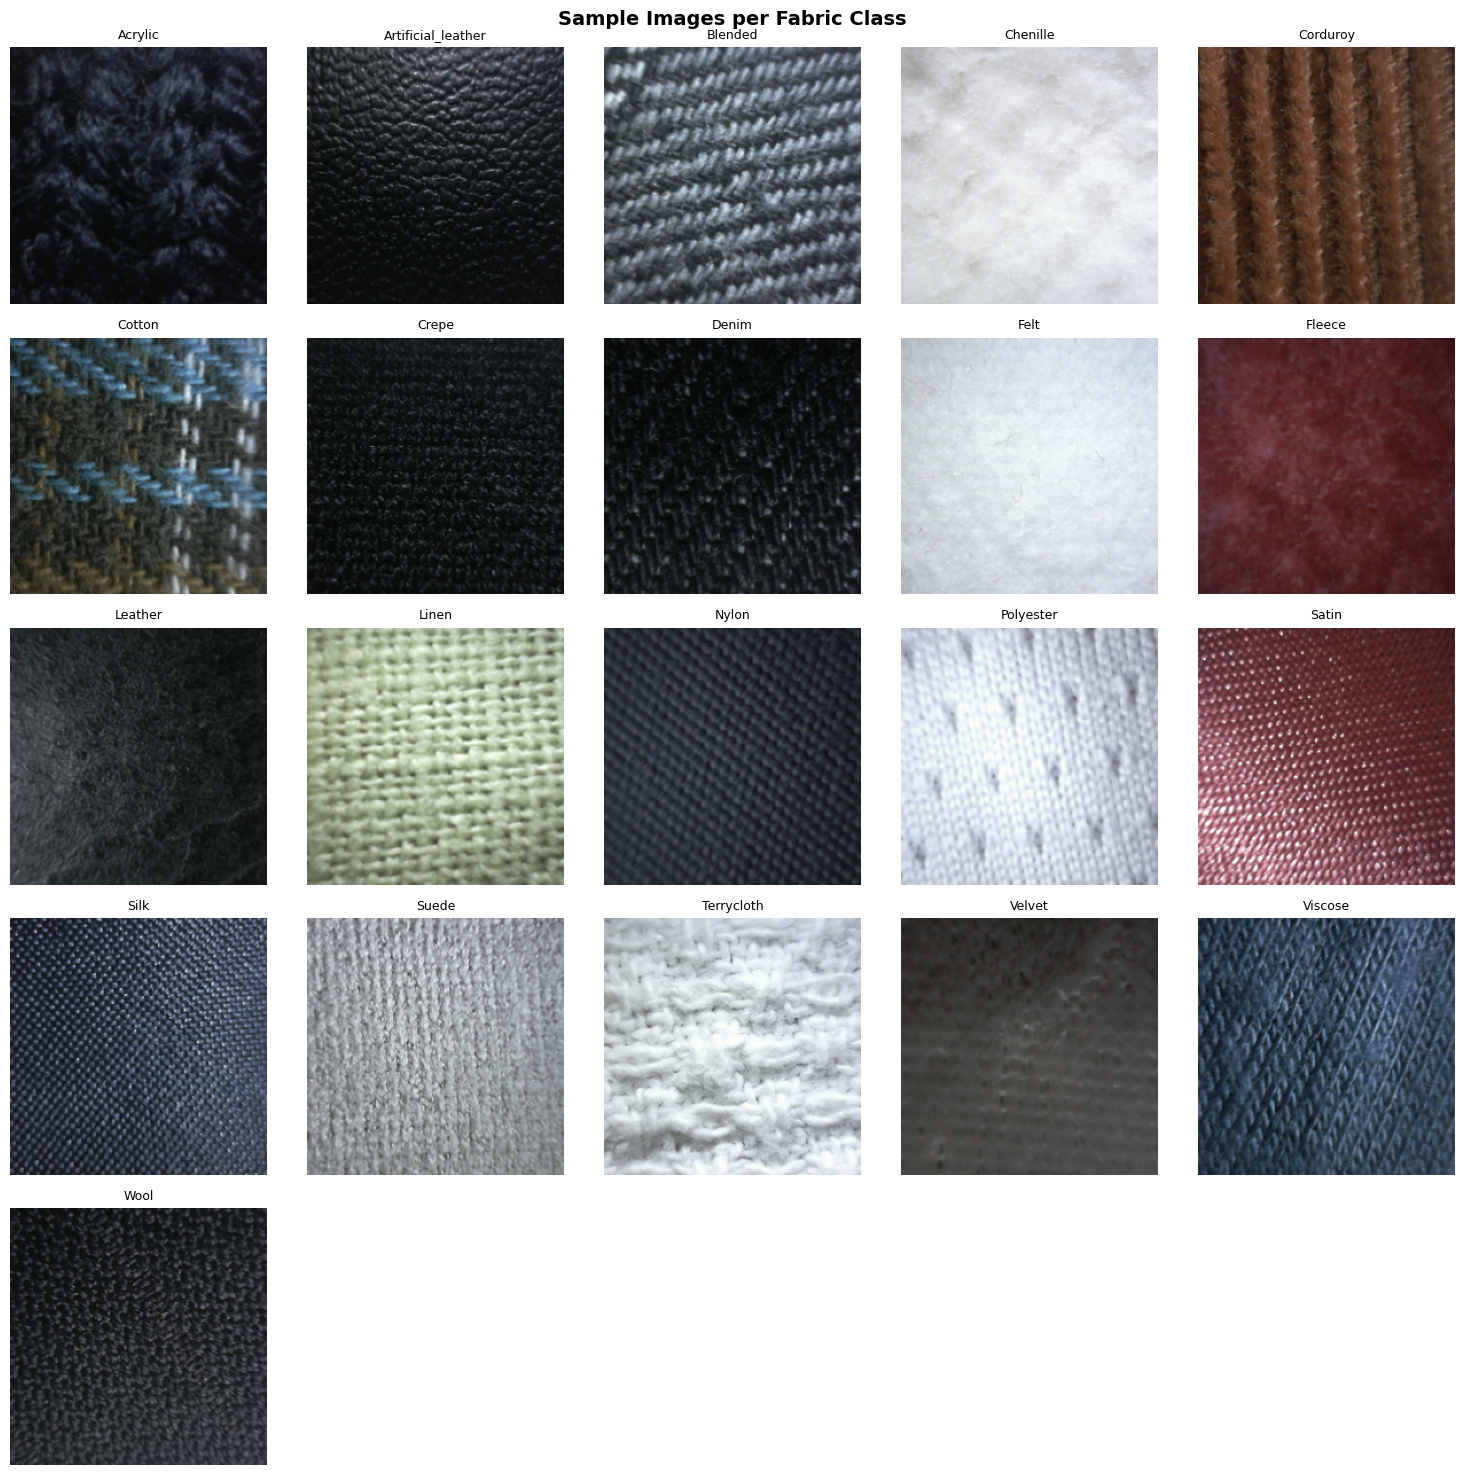

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import random

DATASET_ROOT = r"C:\Users\ASUS\Desktop\AI-Powered-Digital-Marketplace-for-Upcycling-Sri-Lanka-s-Textile-Waste\AI-Powered-Digital-Marketplace-for-Upcycling-Sri-Lanka-s-Textile-Waste\modules\cv\Fabrci type Modelfabric_type_dataset"
train_dir = Path(DATASET_ROOT) / 'train'

classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
print(f"Classes ({len(classes)}): {classes}")

cols = 5
rows = math.ceil(len(classes) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_dir = train_dir / cls
    imgs = list(cls_dir.glob('*.png')) + list(cls_dir.glob('*.jpg'))
    if imgs:
        img = Image.open(random.choice(imgs)).convert('RGB')
        axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis('off')

# Hide unused axes
for j in range(len(classes), len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images per Fabric Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
from pathlib import Path

# ── ⚙️  TRAINING CONFIGURATION ───────────────────────────────────────────────
DATASET_ROOT   = r"C:\Users\ASUS\Desktop\AI-Powered-Digital-Marketplace-for-Upcycling-Sri-Lanka-s-Textile-Waste\AI-Powered-Digital-Marketplace-for-Upcycling-Sri-Lanka-s-Textile-Waste\modules\cv\Fabrci type Model"
IMAGE_SIZE     = 224          # Must match model input (224 for ResNet/EfficientNet)
BATCH_SIZE     = 32
NUM_EPOCHS     = 20
LEARNING_RATE  = 1e-4
DROPOUT_RATE   = 0.4

# Model backbone: 'efficientnet_b0' (recommended) or 'resnet50' or 'resnet18'
BACKBONE       = 'efficientnet_b0'

# Use pretrained weights? (True = transfer learning — much better accuracy)
PRETRAINED     = True

# Freeze backbone? (True = only train classifier head — faster but less accurate)
FREEZE_BACKBONE = False
# ─────────────────────────────────────────────────────────────────────────────

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"⚡ Device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

# ── Data augmentation ─────────────────────────────────────────────────────────
# Fabric textures benefit from rotation, flipping, and color jitter
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ── Datasets & Loaders ────────────────────────────────────────────────────────
data_root = Path(DATASET_ROOT)

train_ds = datasets.ImageFolder(data_root / 'train', transform=train_transforms)
val_ds   = datasets.ImageFolder(data_root / 'val',   transform=val_test_transforms)
test_ds  = datasets.ImageFolder(data_root / 'test',  transform=val_test_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=(DEVICE == 'cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=(DEVICE == 'cuda'))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=(DEVICE == 'cuda'))

CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"\n📂 Dataset loaded:")
print(f"   Train : {len(train_ds):,} images")
print(f"   Val   : {len(val_ds):,} images")
print(f"   Test  : {len(test_ds):,} images")
print(f"   Classes ({NUM_CLASSES}): {CLASS_NAMES}")

⚡ Device: cpu

📂 Dataset loaded:
   Train : 2,648 images
   Val   : 562 images
   Test  : 582 images
   Classes (21): ['Acrylic', 'Artificial_leather', 'Blended', 'Chenille', 'Corduroy', 'Cotton', 'Crepe', 'Denim', 'Felt', 'Fleece', 'Leather', 'Linen', 'Nylon', 'Polyester', 'Satin', 'Silk', 'Suede', 'Terrycloth', 'Velvet', 'Viscose', 'Wool']


In [9]:
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    resnet50,  ResNet50_Weights,
    resnet18,  ResNet18_Weights
)

def build_model(backbone: str, num_classes: int,
                pretrained: bool = True, freeze: bool = False):
    """Build a pretrained CNN with a custom classification head."""

    if backbone == 'efficientnet_b0':
        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=DROPOUT_RATE),
            nn.Linear(in_features, num_classes)
        )

    elif backbone == 'resnet50':
        weights = ResNet50_Weights.DEFAULT if pretrained else None
        model = resnet50(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=DROPOUT_RATE),
            nn.Linear(in_features, num_classes)
        )

    elif backbone == 'resnet18':
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        model = resnet18(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=DROPOUT_RATE),
            nn.Linear(in_features, num_classes)
        )

    else:
        raise ValueError(f"Unknown backbone: {backbone}")

    if freeze:
        for name, param in model.named_parameters():
            # Freeze everything except the final classifier
            if 'classifier' not in name and 'fc' not in name:
                param.requires_grad = False

    return model


model = build_model(BACKBONE, NUM_CLASSES, PRETRAINED, FREEZE_BACKBONE)
model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())

print(f"✅ Model built: {BACKBONE}")
print(f"   Trainable params : {trainable:,}")
print(f"   Total params     : {total:,}")
print(f"   Output classes   : {NUM_CLASSES}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\ASUS/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:33<00:00, 637kB/s] 


✅ Model built: efficientnet_b0
   Trainable params : 4,034,449
   Total params     : 4,034,449
   Output classes   : 21


In [11]:
import time

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # label smoothing helps with many classes

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=LEARNING_RATE, weight_decay=1e-4)

# Cosine annealing LR scheduler — reduces LR smoothly
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

history = {'train_loss': [], 'train_acc': [],
           'val_loss':   [], 'val_acc':   []}

best_val_acc  = 0.0
best_model_wts = None
patience      = 5    # Early stopping patience
patience_ctr  = 0


def run_epoch(loader, training: bool):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    correct = 0
    total   = 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            if training:
                optimizer.zero_grad()

            outputs = model(images)
            loss    = criterion(outputs, labels)

            if training:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    return total_loss / total, correct / total


print(f"🚀 Training for {NUM_EPOCHS} epochs on {DEVICE}...\n")
print(f"  {'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}  {'LR':>8}")
print("  " + "─" * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss,   val_acc   = run_epoch(val_loader,   training=False)

    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    flag = ""
    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        best_model_wts = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr  = 0
        flag = " ⭐"
    else:
        patience_ctr += 1

    elapsed = time.time() - t0
    print(f"  {epoch:>5}  {train_loss:>10.4f}  {train_acc*100:>8.2f}%  "
          f"{val_loss:>8.4f}  {val_acc*100:>6.2f}%  {lr:>8.2e}{flag}")

    if patience_ctr >= patience:
        print(f"\n⏹️  Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
        break

# Restore best weights
model.load_state_dict(best_model_wts)
print(f"\n✅ Training complete! Best val accuracy: {best_val_acc*100:.2f}%")

🚀 Training for 20 epochs on cpu...

  Epoch  Train Loss  Train Acc  Val Loss  Val Acc        LR
  ─────────────────────────────────────────────────────────────────
      1      2.6110     27.87%    2.1688   42.17%  9.94e-05 ⭐
      2      2.0028     45.81%    1.8209   54.09%  9.76e-05 ⭐
      3      1.7064     55.14%    1.6599   58.01%  9.46e-05 ⭐
      4      1.5490     61.40%    1.5177   66.01%  9.05e-05 ⭐
      5      1.4268     65.79%    1.4393   66.37%  8.55e-05 ⭐
      6      1.3463     70.02%    1.3574   70.82%  7.96e-05 ⭐
      7      1.2469     75.15%    1.3218   71.53%  7.30e-05 ⭐
      8      1.1896     77.04%    1.2597   72.60%  6.58e-05 ⭐
      9      1.1531     77.95%    1.2496   72.42%  5.82e-05
     10      1.1143     80.02%    1.1949   75.27%  5.05e-05 ⭐
     11      1.0786     81.80%    1.1649   76.33%  4.28e-05 ⭐
     12      1.0543     82.74%    1.1861   74.56%  3.52e-05
     13      1.0469     82.36%    1.1916   75.62%  2.80e-05
     14      1.0301     83.57%    1.

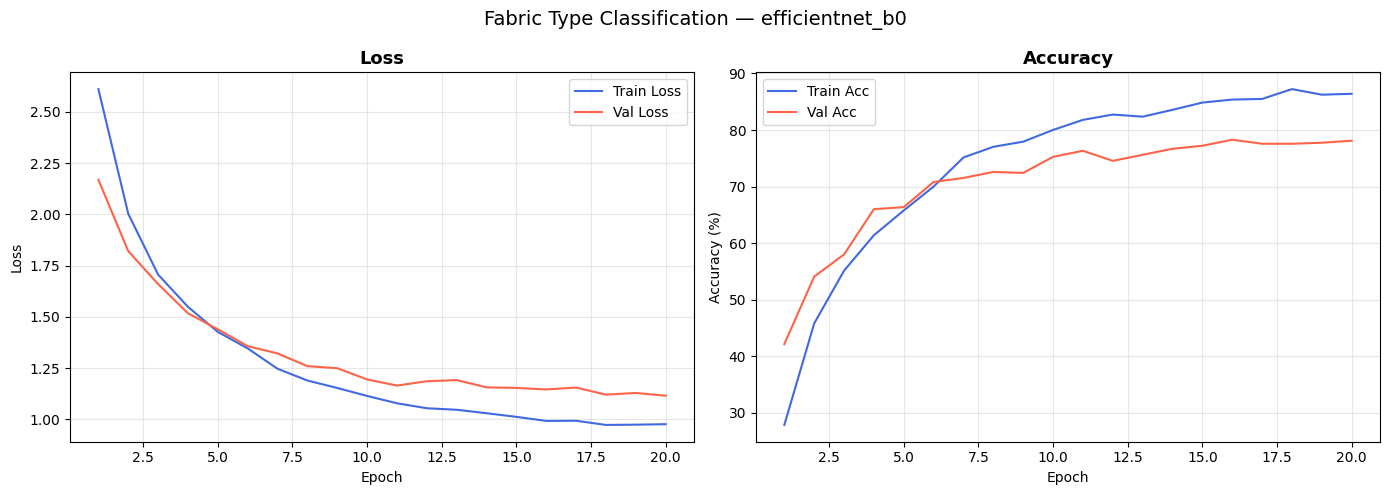

In [13]:
import matplotlib.pyplot as plt

epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(x, history['train_loss'], label='Train Loss', color='royalblue')
ax1.plot(x, history['val_loss'],   label='Val Loss',   color='tomato')
ax1.set_title('Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(x, [a*100 for a in history['train_acc']], label='Train Acc', color='royalblue')
ax2.plot(x, [a*100 for a in history['val_acc']],   label='Val Acc',   color='tomato')
ax2.set_title('Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle(f'Fabric Type Classification — {BACKBONE}', fontsize=14)
plt.tight_layout()
plt.show()

📊 Classification Report:
                    precision    recall  f1-score   support

           Acrylic       0.83      0.62      0.71         8
Artificial_leather       1.00      1.00      1.00         3
           Blended       0.88      0.51      0.64        75
          Chenille       0.86      0.67      0.75         9
          Corduroy       0.88      1.00      0.94        15
            Cotton       0.79      0.72      0.76        75
             Crepe       0.58      0.82      0.68        17
             Denim       0.97      0.99      0.98        75
              Felt       0.33      0.33      0.33         3
            Fleece       1.00      1.00      1.00        21
           Leather       1.00      1.00      1.00         9
             Linen       1.00      1.00      1.00        12
             Nylon       0.74      0.97      0.84        35
         Polyester       0.74      0.71      0.72        75
             Satin       0.50      0.27      0.35        15
              

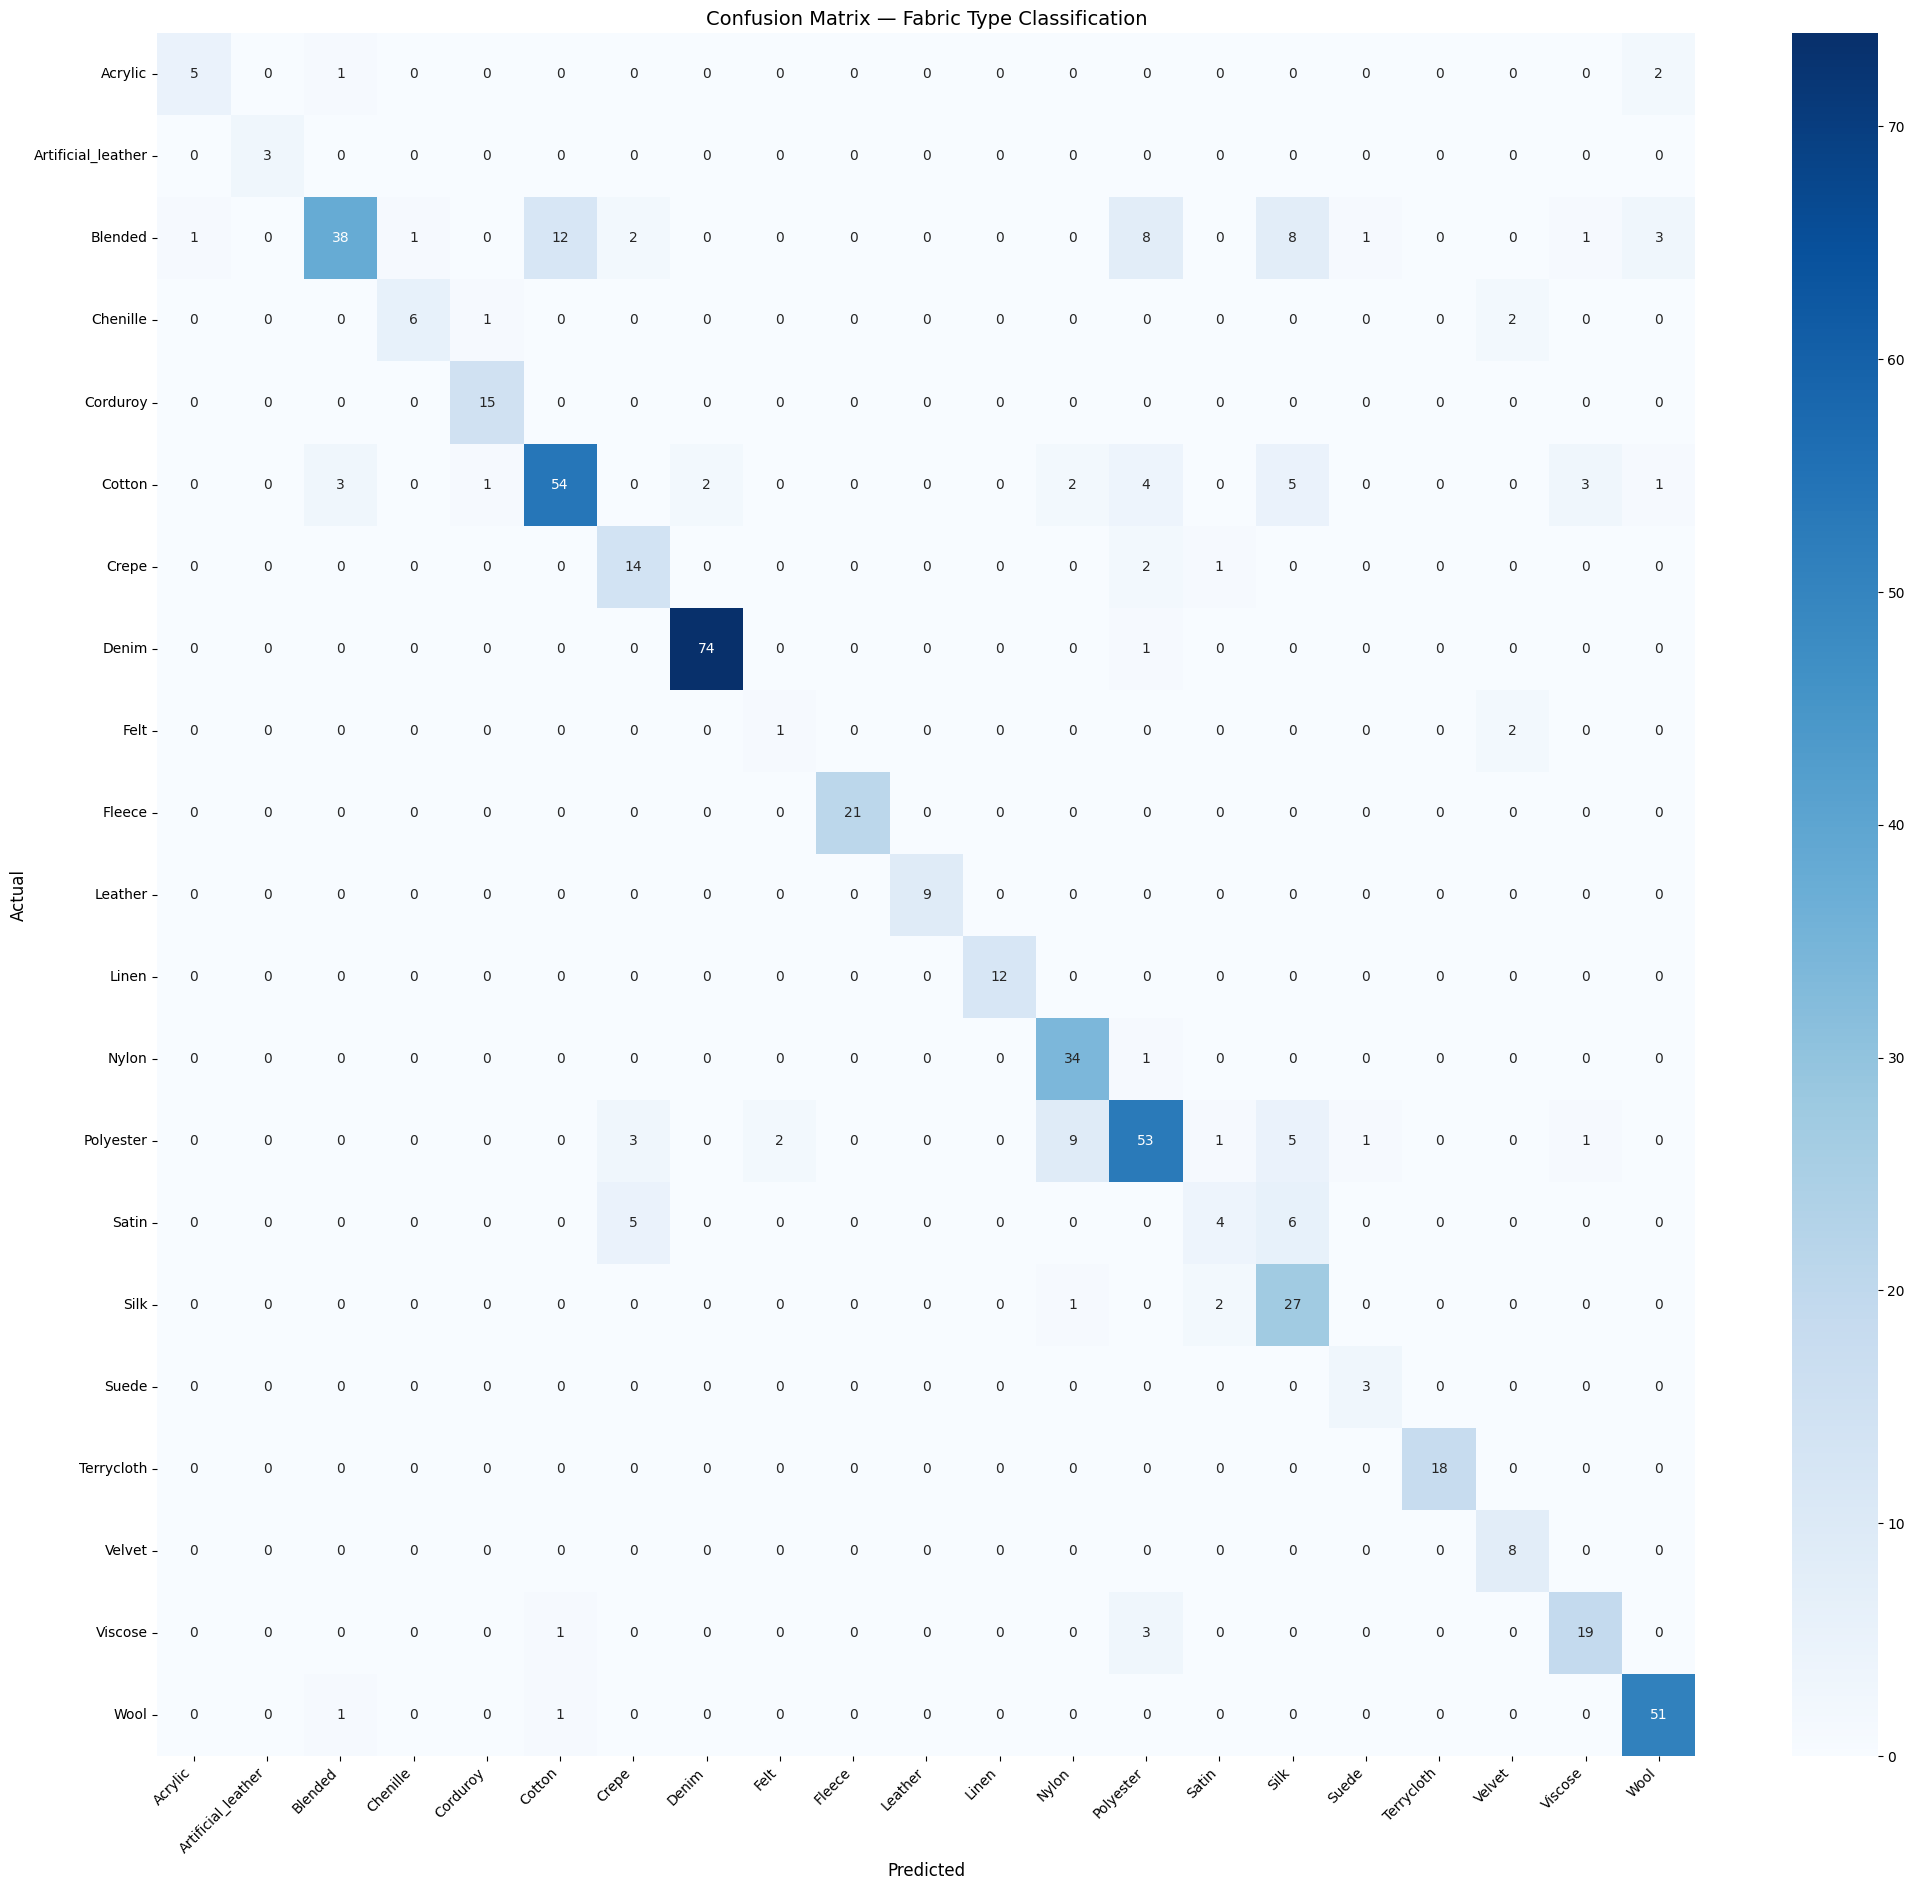

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("📊 Classification Report:")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(max(10, NUM_CLASSES), max(8, NUM_CLASSES - 2)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix — Fabric Type Classification', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
import json

# Save full model state
save_path = 'fabric_type_model_final.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names':      CLASS_NAMES,
    'backbone':         BACKBONE,
    'num_classes':      NUM_CLASSES,
    'image_size':       IMAGE_SIZE,
    'best_val_acc':     best_val_acc,
}, save_path)

# Also save class names separately (useful for inference)
with open('fabric_type_classes.json', 'w') as f:
    json.dump({'classes': CLASS_NAMES, 'backbone': BACKBONE}, f, indent=2)

print(f"✅ Model saved as '{save_path}'")
print(f"✅ Classes saved as 'fabric_type_classes.json'")
print(f"   Best validation accuracy: {best_val_acc*100:.2f}%")
print(f"   Classes: {CLASS_NAMES}")

✅ Model saved as 'fabric_type_model_final.pth'
✅ Classes saved as 'fabric_type_classes.json'
   Best validation accuracy: 78.29%
   Classes: ['Acrylic', 'Artificial_leather', 'Blended', 'Chenille', 'Corduroy', 'Cotton', 'Crepe', 'Denim', 'Felt', 'Fleece', 'Leather', 'Linen', 'Nylon', 'Polyester', 'Satin', 'Silk', 'Suede', 'Terrycloth', 'Velvet', 'Viscose', 'Wool']


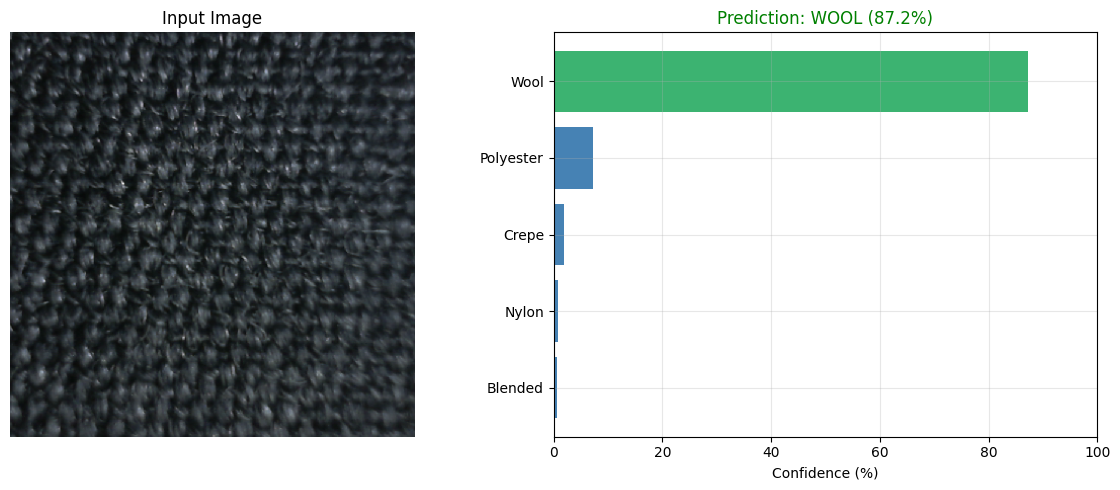


🧵 Fabric Type : WOOL
   Confidence  : 87.2%

Top-5 predictions:
  Wool                  87.22%  █████████████████
  Polyester              7.30%  █
  Crepe                  1.93%  
  Nylon                  0.85%  
  Blended                0.61%  


In [ ]:
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch

# ── ⚙️  SET THIS to the image you want to test ────────────────────────────────
TEST_IMAGE_PATH = r"C:\Users\ASUS\Desktop\AI-Powered-Digital-Marketplace-for-Upcycling-Sri-Lanka-s-Textile-Waste\AI-Powered-Digital-Marketplace-for-Upcycling-Sri-Lanka-s-Textile-Waste\modules\cv\Fabrci type Model\Wool\987\im_1.png"
# ─────────────────────────────────────────────────────────────────────────────

# Load model from checkpoint (run this cell standalone after training)
checkpoint = torch.load('fabric_type_model_final.pth', map_location=DEVICE)
CLASS_NAMES = checkpoint['class_names']
NUM_CLASSES = len(CLASS_NAMES)

infer_model = build_model(checkpoint['backbone'], NUM_CLASSES, pretrained=False)
infer_model.load_state_dict(checkpoint['model_state_dict'])
infer_model = infer_model.to(DEVICE)
infer_model.eval()

# Preprocess image
tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

img = Image.open(TEST_IMAGE_PATH).convert('RGB')
tensor = tf(img).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    output = infer_model(tensor)
    probs  = torch.softmax(output, dim=1)[0].cpu().numpy()

pred_idx   = probs.argmax()
pred_class = CLASS_NAMES[pred_idx]
confidence = probs[pred_idx] * 100

# Top-5 predictions
top5_idx   = probs.argsort()[::-1][:5]
top5_names = [CLASS_NAMES[i] for i in top5_idx]
top5_probs = [probs[i] * 100 for i in top5_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img)
axes[0].set_title('Input Image', fontsize=12)
axes[0].axis('off')

colors = ['mediumseagreen' if n == pred_class else 'steelblue' for n in top5_names]
bars = axes[1].barh(top5_names[::-1], top5_probs[::-1], color=colors[::-1])
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('Confidence (%)')
axes[1].set_title(f'Prediction: {pred_class.upper()} ({confidence:.1f}%)',
                  fontsize=12, color='green')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🧵 Fabric Type : {pred_class.upper()}")
print(f"   Confidence  : {confidence:.1f}%")
print("\nTop-5 predictions:")
for name, prob in zip(top5_names, top5_probs):
    bar = '█' * int(prob / 5)
    print(f"  {name:<20} {prob:>6.2f}%  {bar}")